<a href="https://colab.research.google.com/github/jefreeth/EJ.2/blob/main/markob_web.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


================ SESIÓN SIMULADA ================

    Paso Estado Oculto Acción Observada
0      1     Navegando           Compra
1      2      Buscando           Scroll
2      3     Navegando            Click
3      4     Navegando           Scroll
4      5      Buscando           Scroll
5      6     Navegando           Compra
6      7      Buscando            Click
7      8     Navegando            Click
8      9     Navegando            Click
9     10     Navegando            Click
10    11      Buscando            Click
11    12     Navegando            Click
12    13     Navegando           Scroll
13    14     Navegando            Click
14    15      Buscando            Click
15    16      Buscando            Click
16    17     Navegando           Scroll
17    18     Comprando           Compra
18    19      Buscando            Click
19    20      Buscando            Click
20    21     Navegando            Click
21    22     Navegando           Scroll
22    23     Navegando      

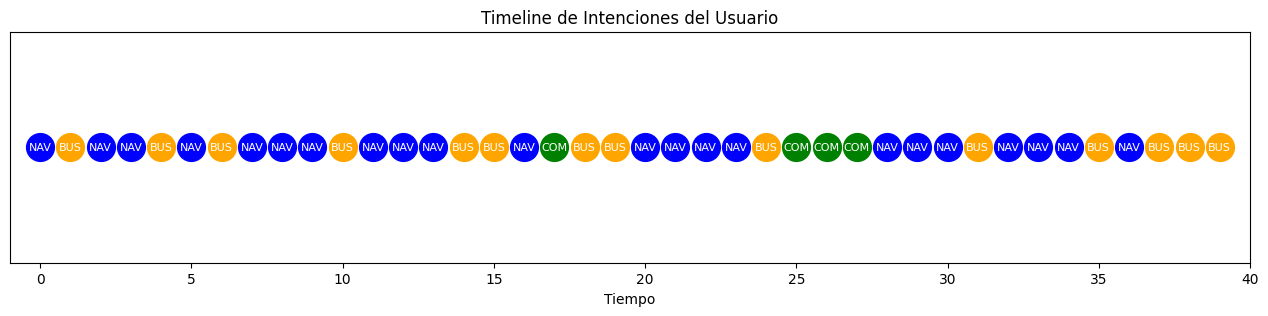

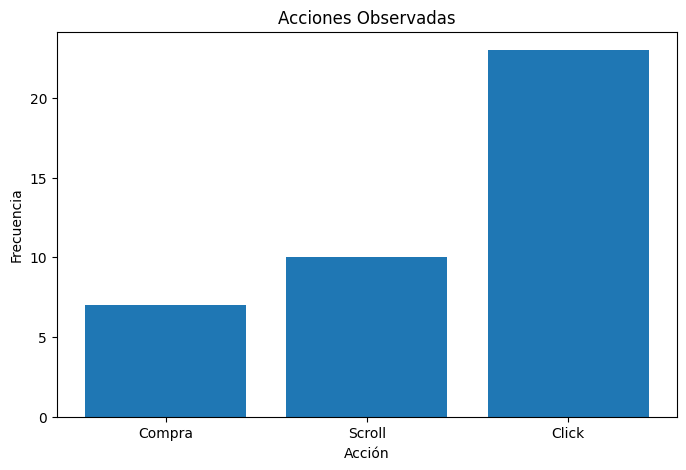

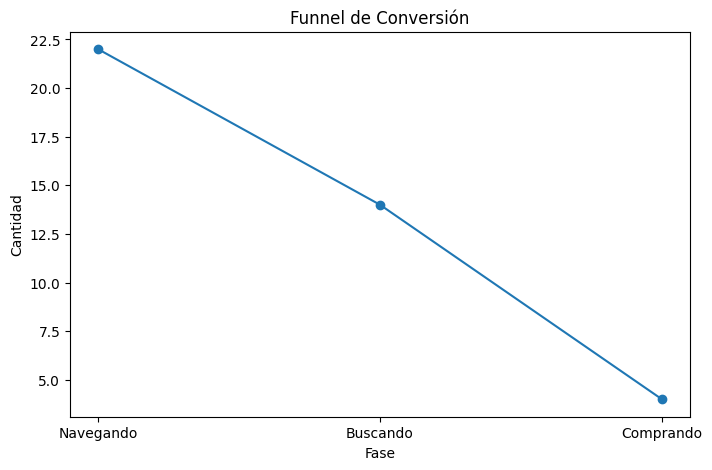

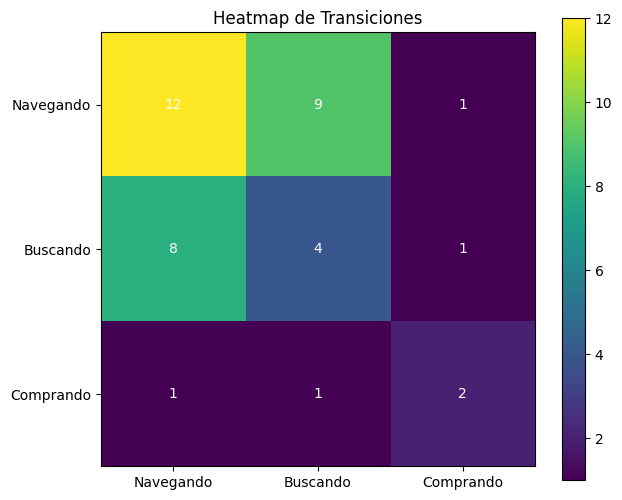

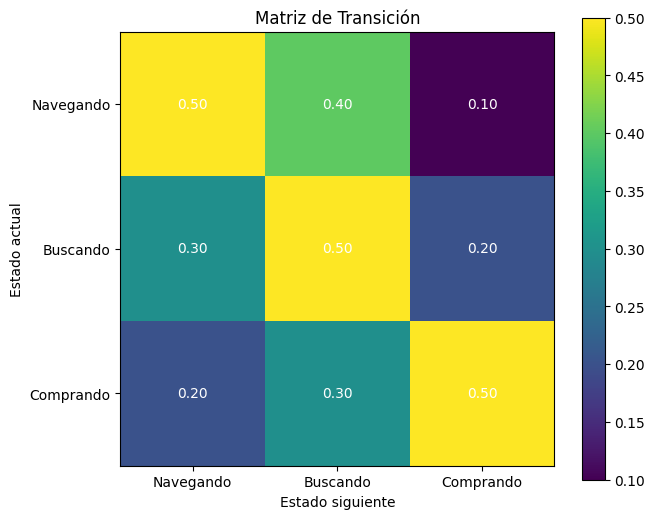

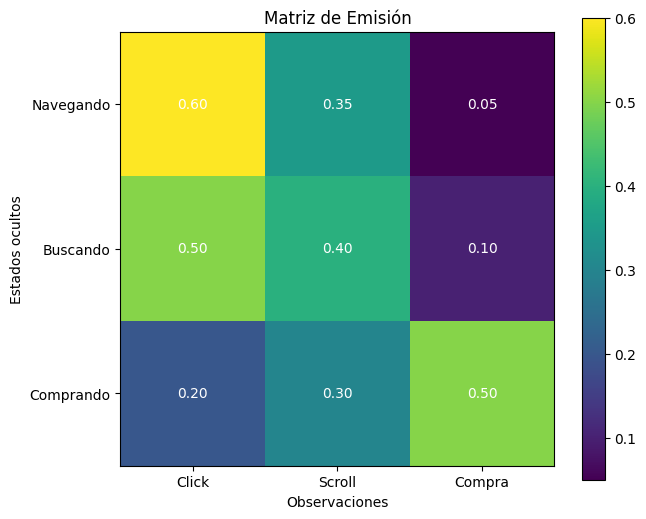

In [ ]:
# ============================================================
# MODELO OCULTO DE MARKOV (HMM) PARA E-COMMERCE
# ============================================================

# ============================================================
# LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random

# ============================================================
# CONFIGURACIÓN
# ============================================================

np.random.seed(42)
random.seed(42)

# ============================================================
# ESTADOS Y OBSERVACIONES
# ============================================================

states = ['Navegando', 'Buscando', 'Comprando']
observations = ['Click', 'Scroll', 'Compra']

# ============================================================
# MATRIZ DE TRANSICIÓN
# ============================================================

transition_matrix = np.array([
    [0.5, 0.4, 0.1],  # Navegando
    [0.3, 0.5, 0.2],  # Buscando
    [0.2, 0.3, 0.5]   # Comprando
])

# ============================================================
# MATRIZ DE EMISIÓN
# ============================================================

emission_matrix = np.array([
    [0.6, 0.35, 0.05],  # Navegando
    [0.5, 0.4, 0.1],    # Buscando
    [0.2, 0.3, 0.5]     # Comprando
])

# ============================================================
# DISTRIBUCIÓN INICIAL
# ============================================================

initial_distribution = np.array([0.6, 0.3, 0.1])

# ============================================================
# CLASE HMM
# ============================================================

class EcommerceHMM:

    def __init__(self,
                 states,
                 observations,
                 transition_matrix,
                 emission_matrix,
                 initial_distribution):

        self.states = states
        self.observations = observations
        self.transition_matrix = transition_matrix
        self.emission_matrix = emission_matrix
        self.initial_distribution = initial_distribution

    # --------------------------------------------------------
    # SIMULACIÓN DE SESIÓN
    # --------------------------------------------------------

    def simulate_session(self, n_steps=40):

        hidden_states = []
        observed_actions = []

        # Estado inicial
        current_state = np.random.choice(
            self.states,
            p=self.initial_distribution
        )

        for _ in range(n_steps):

            hidden_states.append(current_state)

            state_index = self.states.index(current_state)

            # Generar observación
            action = np.random.choice(
                self.observations,
                p=self.emission_matrix[state_index]
            )

            observed_actions.append(action)

            # Transición al siguiente estado
            current_state = np.random.choice(
                self.states,
                p=self.transition_matrix[state_index]
            )

        return hidden_states, observed_actions

    # --------------------------------------------------------
    # PREDICTOR DE CONVERSIÓN
    # --------------------------------------------------------

    def predict_conversion(self, action_sequence):

        compra_count = action_sequence.count("Compra")
        click_count = action_sequence.count("Click")
        scroll_count = action_sequence.count("Scroll")

        score = (
            compra_count * 0.6 +
            click_count * 0.2 +
            scroll_count * 0.2
        )

        probability = min(score / len(action_sequence), 1)

        if probability > 0.45:
            prediction = "ALTA probabilidad de compra"

        elif probability > 0.30:
            prediction = "MEDIA probabilidad de compra"

        else:
            prediction = "BAJA probabilidad de compra"

        return probability, prediction

# ============================================================
# CREAR MODELO
# ============================================================

hmm = EcommerceHMM(
    states,
    observations,
    transition_matrix,
    emission_matrix,
    initial_distribution
)

# ============================================================
# SIMULAR SESIÓN
# ============================================================

hidden_states, observed_actions = hmm.simulate_session(40)

# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame({
    'Paso': range(1, 41),
    'Estado Oculto': hidden_states,
    'Acción Observada': observed_actions
})

print("\n================ SESIÓN SIMULADA ================\n")
print(df)

# ============================================================
# MÉTRICAS E-COMMERCE
# ============================================================

# ------------------------------------------------------------
# TASA DE CONVERSIÓN
# ------------------------------------------------------------

conversion_rate = (
    hidden_states.count("Comprando") / len(hidden_states)
) * 100

# ------------------------------------------------------------
# TIEMPO EN CADA FASE
# ------------------------------------------------------------

state_counts = Counter(hidden_states)

# ------------------------------------------------------------
# PUNTOS DE ABANDONO
# ------------------------------------------------------------

abandonments = 0

for i in range(1, len(hidden_states)):

    previous_state = hidden_states[i - 1]
    current_state = hidden_states[i]

    if previous_state != "Navegando" and current_state == "Navegando":
        abandonments += 1

# ------------------------------------------------------------
# CAMINO MÁS COMÚN
# ------------------------------------------------------------

transitions = []

for i in range(len(hidden_states) - 1):

    transition = (
        hidden_states[i],
        hidden_states[i + 1]
    )

    transitions.append(transition)

most_common_path = Counter(transitions).most_common(1)

# ============================================================
# RESULTADOS
# ============================================================

print("\n================ MÉTRICAS ==================\n")

print(f"Tasa de conversión: {conversion_rate:.2f}%")

print("\nTiempo promedio en cada fase:")

for state, count in state_counts.items():
    print(f"{state}: {count} pasos")

print(f"\nPuntos de abandono: {abandonments}")

print("\nCamino más común:")

for path, freq in most_common_path:
    print(f"{path} -> {freq} veces")

# ============================================================
# PREDICTOR DE CONVERSIÓN
# ============================================================

test_sequence = [
    'Click',
    'Scroll',
    'Click',
    'Compra',
    'Compra'
]

probability, prediction = hmm.predict_conversion(test_sequence)

print("\n================ PREDICTOR ==================\n")

print("Secuencia:", test_sequence)
print(f"Probabilidad: {probability:.2f}")
print("Resultado:", prediction)

# ============================================================
# PATRONES DE USUARIO
# ============================================================

buyers = []
non_buyers = []

for i in range(len(hidden_states)):

    if hidden_states[i] == "Comprando":
        buyers.append(observed_actions[i])

    else:
        non_buyers.append(observed_actions[i])

print("\n================ PATRONES ==================\n")

print("Usuarios que convierten:")
print(Counter(buyers))

print("\nUsuarios que NO convierten:")
print(Counter(non_buyers))

# ============================================================
# RECOMENDACIONES UX
# ============================================================

print("\n================ RECOMENDACIONES UX ==================\n")

if abandonments > 5:
    print("- Mejorar navegación para reducir abandono.")

if conversion_rate < 30:
    print("- Optimizar proceso de compra.")

if state_counts['Buscando'] > state_counts['Comprando']:
    print("- Mejorar buscadores y filtros.")

print("- Mostrar recomendaciones personalizadas.")
print("- Reducir pasos del checkout.")
print("- Optimizar velocidad del sitio.")

# ============================================================
# FUNNEL ANALYSIS
# ============================================================

funnel_data = {
    'Navegando': hidden_states.count('Navegando'),
    'Buscando': hidden_states.count('Buscando'),
    'Comprando': hidden_states.count('Comprando')
}

# ============================================================
# VISUALIZACIONES
# ============================================================

# ------------------------------------------------------------
# TIMELINE DE INTENCIONES
# ------------------------------------------------------------

colors = {
    'Navegando': 'blue',
    'Buscando': 'orange',
    'Comprando': 'green'
}

labels = {
    'Navegando': 'NAV',
    'Buscando': 'BUS',
    'Comprando': 'COM'
}

plt.figure(figsize=(16, 3))

for i, state in enumerate(hidden_states):

    plt.scatter(
        i,
        0,
        color=colors[state],
        s=400
    )

    plt.text(
        i,
        0,
        labels[state],
        ha='center',
        va='center',
        color='white',
        fontsize=8
    )

plt.xlim(-1, 40)
plt.yticks([])
plt.title("Timeline de Intenciones del Usuario")
plt.xlabel("Tiempo")

plt.show()

# ------------------------------------------------------------
# GRÁFICO DE ACCIONES OBSERVADAS
# ------------------------------------------------------------

action_counts = Counter(observed_actions)

plt.figure(figsize=(8, 5))

plt.bar(
    action_counts.keys(),
    action_counts.values()
)

plt.title("Acciones Observadas")
plt.xlabel("Acción")
plt.ylabel("Frecuencia")

plt.show()

# ------------------------------------------------------------
# FUNNEL DE CONVERSIÓN
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    list(funnel_data.keys()),
    list(funnel_data.values()),
    marker='o'
)

plt.title("Funnel de Conversión")
plt.xlabel("Fase")
plt.ylabel("Cantidad")

plt.show()

# ------------------------------------------------------------
# HEATMAP DE TRANSICIONES
# ------------------------------------------------------------

transition_counts = np.zeros((3, 3))

state_to_index = {
    'Navegando': 0,
    'Buscando': 1,
    'Comprando': 2
}

for i in range(len(hidden_states) - 1):

    current_state = hidden_states[i]
    next_state = hidden_states[i + 1]

    row = state_to_index[current_state]
    col = state_to_index[next_state]

    transition_counts[row][col] += 1

plt.figure(figsize=(7, 6))

plt.imshow(transition_counts)

plt.xticks(range(3), states)
plt.yticks(range(3), states)

plt.colorbar()

plt.title("Heatmap de Transiciones")

for i in range(3):
    for j in range(3):

        plt.text(
            j,
            i,
            int(transition_counts[i, j]),
            ha='center',
            va='center',
            color='white'
        )

plt.show()

# ============================================================
# MATRIZ DE TRANSICIÓN
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(transition_matrix)

plt.title("Matriz de Transición")
plt.xlabel("Estado siguiente")
plt.ylabel("Estado actual")

plt.xticks(range(len(states)), states)
plt.yticks(range(len(states)), states)

for i in range(len(states)):
    for j in range(len(states)):

        plt.text(
            j,
            i,
            f"{transition_matrix[i][j]:.2f}",
            ha='center',
            va='center',
            color='white'
        )

plt.colorbar()

plt.show()

# ============================================================
# MATRIZ DE EMISIÓN
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(emission_matrix)

plt.title("Matriz de Emisión")
plt.xlabel("Observaciones")
plt.ylabel("Estados ocultos")

plt.xticks(range(len(observations)), observations)
plt.yticks(range(len(states)), states)

for i in range(len(states)):
    for j in range(len(observations)):

        plt.text(
            j,
            i,
            f"{emission_matrix[i][j]:.2f}",
            ha='center',
            va='center',
            color='white'
        )

plt.colorbar()

plt.show()

# ============================================================
# FIN
# ============================================================